In [1]:
# Copyright (C) 2025 Richard Stiskalek
# This program is free software; you can redistribute it and/or modify it
# under the terms of the GNU General Public License as published by the
# Free Software Foundation; either version 3 of the License, or (at your
# option) any later version.
#
# This program is distributed in the hope that it will be useful, but
# WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU General
# Public License for more details.
#
# You should have received a copy of the GNU General Public License along
# with this program; if not, write to the Free Software Foundation, Inc.,
# 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301, USA.
import sys

import numpy as np
import matplotlib.pyplot as plt
from h5py import File
import csiborgtools
sys.path.append("../")
from reconstruction_comparison import *

%load_ext autoreload
%autoreload 2
%matplotlib inline

paths = csiborgtools.read.Paths(**csiborgtools.paths_glamdring)
SPEED_OF_LIGHT = 299792.458  # km / s

In [77]:
def raj_to_deg(raj_str):
    raj_str = raj_str.zfill(7)
    hours = int(raj_str[:2])
    minutes = int(raj_str[2:4])
    seconds = float(raj_str[4:])
    return 15 * (hours + minutes / 60 + seconds / 3600)

def decj_to_deg(decj_str):
    decj_str = decj_str.strip()

    sign = -1 if decj_str.startswith('-') else 1
    decj_str = decj_str.lstrip('+-').zfill(7)

    degrees = int(decj_str[:2])
    minutes = int(decj_str[2:4])
    seconds = float(decj_str[4:])

    return sign * (degrees + minutes / 60 + seconds / 3600)


def read_CF4_cepheids(shoes_only=False):
    fname = "/mnt/extraspace/rstiskalek/catalogs/PV/CF4/CF4_cepheids.txt"

    pgc = []
    name = []
    RA = []
    DEC = []
    DM21 = []
    e_DM = []
    R = []
    Vhel = []
    with open(fname, "r") as f:
        cols = f.readline().strip().split(",")
        i_pgc = cols.index("pgc")
        i_name = cols.index("Name")
        i_R = cols.index("R")
        i_RA = cols.index("RAJ")
        i_DEC = cols.index("DeJ")
        i_DM21 = cols.index("DM21")
        i_DM = cols.index("eDM")
        i_Vhel = cols.index("Vhel")

        for line in f:
            vals = line.strip().split(",")
            pgc.append(int(vals[i_pgc]))
            name.append(vals[i_name])
            RA.append(vals[i_RA])
            DEC.append(vals[i_DEC])
            DM21.append(float(vals[i_DM21]))
            R.append(vals[i_R])
            e_DM.append(float(vals[i_DM]))
            Vhel.append(float(vals[i_Vhel]))

    for i, name_i in enumerate(name):
        if "MRK" in name_i:
            name[i] = name_i.replace("MRK", "M")

        if "NGC" in name_i:
            name[i] = name_i.replace("NGC", "N")

        if "UGC" in name_i:
            name[i] = name_i.replace("UGC", "U")

    RA = [raj_to_deg(ra) for ra in RA]
    DEC = [decj_to_deg(dec) for dec in DEC]
    dtype = [("pgc", int), ("name", "U10"), ("RA", float), ("DEC", float),
             ("DM21", float), ("R", "U1"), ("Vhel", float), ("e_DM", float)]

    arr = np.array(
        list(zip(pgc, name, RA, DEC, DM21, R, Vhel, e_DM)), dtype=dtype)

    if shoes_only:
        m = arr["R"] == "R"
        arr = arr[m]


    return arr


CF4_cepheids = read_CF4_cepheids(shoes_only=False)

fname_out = "/mnt/extraspace/rstiskalek/catalogs/PV/CF4/CF4_cepheids_processed.npy"
print(f"save to `{fname_out}`")
np.save(fname_out, CF4_cepheids)



save to `/mnt/extraspace/rstiskalek/catalogs/PV/CF4/CF4_cepheids_processed.npy`


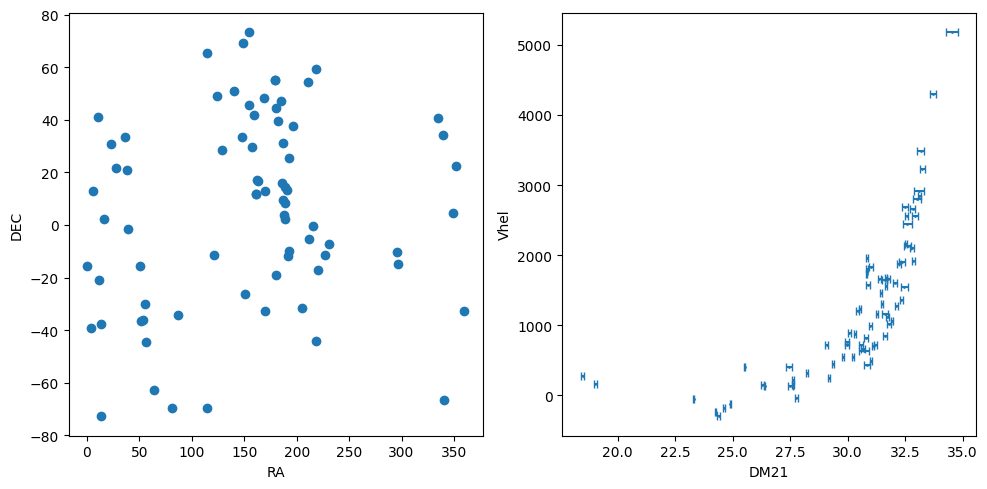

In [44]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs_sky = axs[0]
axs_sky.scatter(CF4_cepheids["RA"], CF4_cepheids["DEC"])
axs_sky.set_xlabel("RA")
axs_sky.set_ylabel("DEC")

axs_dist = axs[1]
axs_dist.errorbar(CF4_cepheids["DM21"], CF4_cepheids["Vhel"], xerr=CF4_cepheids["e_DM"], fmt="o", ms=1, capsize=3)
axs_dist.set_xlabel("DM21")
axs_dist.set_ylabel("Vhel")

fig.tight_layout()
fig.show()



In [45]:
names_shoes = np.genfromtxt("table2.tex", delimiter="&", usecols=0, dtype=str)
names_shoes = np.asarray([name.strip() for name in names_shoes]).astype('<U7')
# Change to unique for now
names_shoes = np.unique(names_shoes)

In [46]:
print("These objects from SH0ES are not in CF4:")
for name in names_shoes:
    if name not in CF4_cepheids["name"]:
        print(name)

These objects from SH0ES are not in CF4:
M101
M31
N0691
N105A
N976A


In [68]:
fname = "/mnt/extraspace/rstiskalek/catalogs/PV/CF4/CF4_TFR_cluster.hdf5"
with File(fname, "r") as f:
    pgc = f["pgc"][...]
    host = f["host"][...]
    # Nest = f["Nest"][...]
    RA = f["RA"][...] * 360 / 24
    DEC = f["DE"][...]
    Vcmb = f["Vcmb"][...]

    w1 = f["w1"][...]
    i = f["i"][...]
    Qw = f["Qw"][...]
    Qs = f["Qs"][...]

    e_mag = np.ones_like(w1) * 0.05

    eta = f["lgWmxi"][...] - 2.5
    e_eta = f["elgWi"][...]
    


indx_CF4, indx_calibrators = [], []

for i in range(len(CF4_cepheids)):
    pgc_i = CF4_cepheids["pgc"][i]
    if pgc_i in pgc:
        indx_calibrators.append(i)

        j = np.where(pgc == pgc_i)[0][0]
        indx_CF4.append(j)

indx_CF4 = np.asarray(indx_CF4)
indx_calibrators = np.asarray(indx_calibrators)
    

In [69]:
indx_CF4, indx_calibrators

(array([ 118,  334,  393,  674,  774, 1107, 1541, 1581, 1598, 1729, 1987,
        2273, 2412, 2460, 2575, 2854, 3058, 3092, 3149, 3258, 3329, 3413,
        3483, 3487, 3723, 3735, 4100, 4375, 4473, 4483, 4564, 4566, 4651,
        4721, 4742, 5444, 5634, 5814, 7075, 7174, 7418, 7750]),
 array([ 1,  4,  6,  8,  9, 10, 15, 16, 17, 18, 20, 22, 23, 24, 25, 26, 27,
        28, 29, 31, 32, 33, 35, 36, 39, 40, 41, 46, 48, 49, 51, 52, 54, 56,
        57, 62, 65, 66, 70, 71, 73, 75]))

In [82]:
from csiborgtools.flow import Distmod2Distance
distmod2dist = Distmod2Distance(0.3)

In [58]:
m = ((w1 > 5) & (Qw == 5) & np.isin(pgc, pgc_calibrators))
m.sum()

33

In [59]:
ii = np.where(((w1 > 5) & (Qw == 5) & np.isin(pgc, pgc_calibrators)))
ii

(array([ 118,  334,  393, 1107, 1541, 1581, 1598, 1729, 1987, 2273, 2412,
        2460, 2575, 2854, 3058, 3092, 3413, 3483, 3487, 3723, 3735, 4100,
        4375, 4473, 4564, 4566, 4651, 4721, 5634, 5814, 7075, 7174, 7750]),)

In [60]:
jj = np.where(((i > 5) & (Qs == 5) & np.isin(pgc, pgc_calibrators)))
jj 

(array([2460, 2575, 2854, 3058, 3092, 3258, 3329, 3413, 3483, 3487, 4100,
        4375, 4473, 4564, 4566, 4651, 4721, 5444, 7174]),)

In [53]:
np.unique(np.hstack([ii, jj])).shape

(36,)

In [16]:
unique_hosts, counts = np.unique(host, return_counts=True)
unique_hosts = unique_hosts[1:]
counts = counts[1:]

m = (counts > 5) & (unique_hosts != b'"ZP calibr')
unique_hosts = unique_hosts[m]
counts = counts[m]

for i, h in enumerate(unique_hosts):
    print(h, counts[i])


b'"Abell 136' 69
b'"Abell 215' 39
b'"Abell 262' 57
b'"Abell 263' 30
b'"Abell 400' 24
b'"Abell 539' 22
b'"Ursa Majo' 38
b'Antlia' 17
b'Cancer' 18
b'Centaurus' 22
b'Coma' 79
b'Fornax' 19
b'Hydra' 44
b'NGC4065' 14
b'NGC410' 35
b'NGC507' 23
b'NGC70' 11
b'NGC80' 14
b'Pegasus' 27
b'Virgo' 37


In [174]:
m = (host == b'"Abell 136') #| (host == b'Virgo')
m2 = (host == b'Coma') #| (host == b'Virgo')

m &= (w1 > 5) & (Qw == 5)
m2 &= (w1 > 5) & (Qw == 5)

In [175]:
m.sum(), m2.sum()

(36, 42)

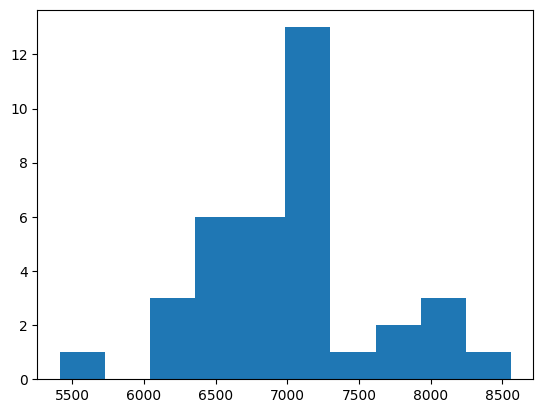

In [176]:
plt.figure()
plt.hist(Vcmb[m], bins="auto")
plt.show()

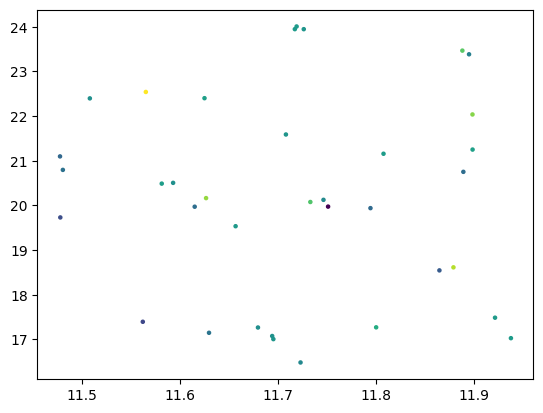

In [177]:
plt.figure()
plt.scatter(RA[m], DEC[m], c=Vcmb[m], s=5)



plt.show()

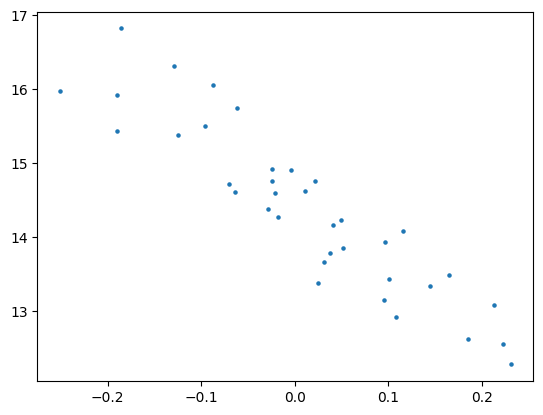

In [178]:
plt.figure()
plt.scatter(eta[m], w1[m], s=5)
plt.show()

In [179]:
Vcmb[m2].mean() / 100, Vcmb[m2].std()/ 100

(71.36690476190476, 12.214955409562345)

In [180]:
from jax.random import PRNGKey
from numpyro.infer import MCMC, NUTS, init_to_sample
from numpyro import sample, plate, factor
from numpyro.distributions import Normal, Uniform



dist2distmod = csiborgtools.flow.ComovingDistance2Distmod()

def model(eta, mag, e_eta, e_mag, eta2, mag2, e_eta2, e_mag2):
    a = sample("aTFR", Normal(-20, 2))
    b = sample("bTFR", Normal(-8, 2))
    c = sample("cTFR", Normal(10, 5))
    sigma = sample("sigmaTFR", Uniform(0, 1))

    eta_mean = sample("eta_mean", Normal(0, 1))
    eta_width = sample("eta_width", Uniform(0, 1))

    with plate("plate_eta", len(eta)):
        eta_true = sample("eta_true", Normal(eta_mean, eta_width))

    factor("ll_eta", Normal(eta_true, e_eta).log_prob(eta))

    with plate("plate_eta2", len(eta2)):
        eta2_true = sample("eta2_true", Normal(eta_mean, eta_width))

    factor("ll_eta2", Normal(eta2_true, e_eta2).log_prob(eta2))


    M_TFR = a + eta_true * b
    M_TFR = jnp.where(eta_true > 0, M_TFR + c * eta_true**2, M_TFR) 
    with plate("plate_absmag", len(mag)):
        absmag = sample("absmag", Normal(M_TFR, sigma))
    # 
    M_TFR2 = a + eta2_true * b
    M_TFR2 = jnp.where(eta2_true > 0, M_TFR2 + c * eta2_true**2, M_TFR2)
    with plate("plate_absmag2", len(mag2)):
        absmag2 = sample("absmag2", Normal(M_TFR2, sigma))
    
    dist = sample("dist", Normal(90.1, 4.3))
    distmod = dist2distmod(dist)

    dist2 = sample("dist2", Normal(71, 12.2))
    distmod2 = dist2distmod(dist2)

    mag_true = absmag + distmod

    with plate("plate_mag", len(mag)):
        sample("ll_mag", Normal(mag_true, e_mag), obs=mag)

    mag_true2 = absmag2 + distmod2
    with plate("plate_mag2", len(mag2)):
        sample("ll_mag2", Normal(mag_true2, e_mag2), obs=mag2)



In [181]:
kwargs = dict(
    eta=eta[m], mag=w1[m], e_eta=e_eta[m], e_mag=e_mag[m],
    eta2=eta[m2], mag2=w1[m2], e_eta2=e_eta[m2], e_mag2=e_mag[m2]
    )


nuts_kernel = NUTS(model, init_strategy=init_to_sample())
mcmc = MCMC(nuts_kernel, num_warmup=500, num_samples=5000)
mcmc.run(PRNGKey(42), **kwargs)

samples = mcmc.get_samples()
mcmc.print_summary()

sample: 100%|██████████| 5500/5500 [00:09<00:00, 582.26it/s, 31 steps of size 9.50e-02. acc. prob=0.90] 



                   mean       std    median      5.0%     95.0%     n_eff     r_hat
         aTFR    -20.30      0.12    -20.30    -20.50    -20.10     62.48      1.00
    absmag[0]    -20.61      0.11    -20.61    -20.79    -20.42     73.73      1.00
    absmag[1]    -20.02      0.11    -20.01    -20.20    -19.83     77.10      1.00
    absmag[2]    -22.21      0.11    -22.21    -22.40    -22.03     77.88      1.00
    absmag[3]    -20.16      0.11    -20.16    -20.35    -19.98     75.99      1.00
    absmag[4]    -20.39      0.11    -20.39    -20.57    -20.20     76.37      1.00
    absmag[5]    -20.02      0.11    -20.02    -20.22    -19.85     77.06      1.00
    absmag[6]    -21.34      0.11    -21.34    -21.53    -21.16     77.83      1.00
    absmag[7]    -20.70      0.11    -20.70    -20.88    -20.51     74.39      1.00
    absmag[8]    -20.17      0.11    -20.17    -20.36    -19.99     76.37      1.00
    absmag[9]    -19.34      0.11    -19.34    -19.53    -19.15     77.60  

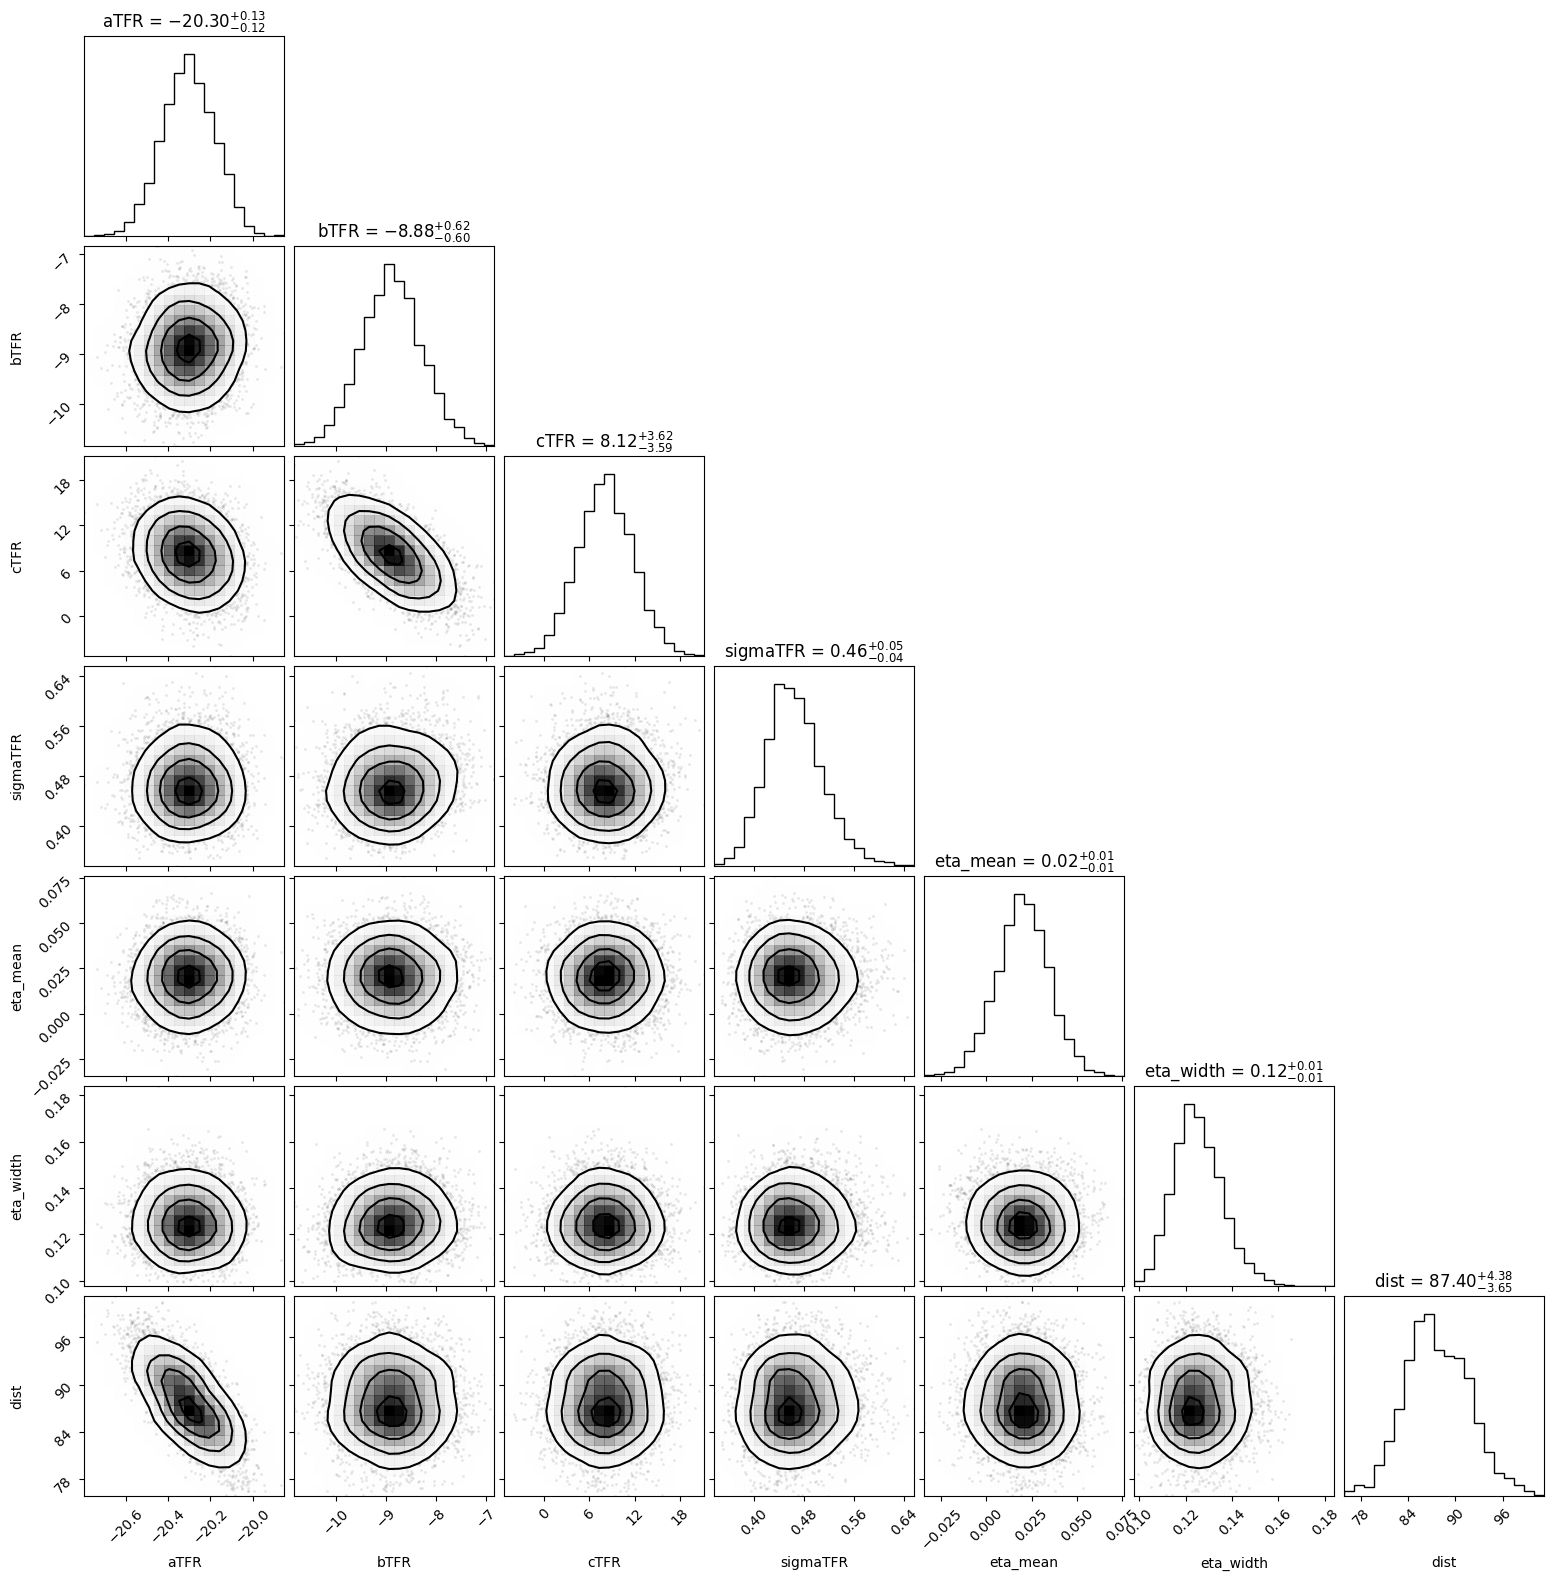

In [182]:
from corner import corner

keys = ["aTFR", "bTFR", "cTFR", "sigmaTFR", "eta_mean", "eta_width", "dist"]
data = np.vstack([samples[key] for key in keys]).T

fig = corner(data, labels=keys, show_titles=True, title_fmt=".2f", smooth=1)

fig.show()
